In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

# Load files
nav = pd.read_csv("../data/processd/clean_nav_history.csv")
performance = pd.read_csv("../data/processd/clean_performance.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

nav['date'] = pd.to_datetime(nav['date'])

print(nav.head())

   amfi_code       date       nav
0     100016 2022-01-03  520.4608
1     100016 2022-01-04  515.0971
2     100016 2022-01-05  521.7239
3     100016 2022-01-06  515.7880
4     100016 2022-01-07  515.1639


In [2]:
nav = nav.sort_values(
    ['amfi_code','date']
)

nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
    .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [3]:
annual_returns = (
    nav.groupby('amfi_code')['daily_return']
    .apply(
        lambda x:
        (1+x.dropna()).prod()
        **(252/len(x.dropna()))
        - 1
    )
)

annual_returns = annual_returns.reset_index()

annual_returns.columns = [
    'amfi_code',
    'annualized_return'
]

annual_returns.to_csv(
    "../reports/returns_computed.csv",
    index=False
)

In [4]:
def calculate_cagr(df):
    
    start_nav = df.iloc[0]['nav']
    end_nav = df.iloc[-1]['nav']

    years = (
        (df.iloc[-1]['date']
         - df.iloc[0]['date']).days
    ) / 365

    return (
        (end_nav/start_nav)
        **(1/years)
        - 1
    )

In [5]:
cagr = (
    nav.groupby('amfi_code')
    .apply(calculate_cagr)
    .reset_index()
)

cagr.columns = [
    'amfi_code',
    'cagr'
]

cagr.to_csv(
    "../reports/cagr_report.csv",
    index=False
)

C:\Users\Dell\AppData\Local\Temp\ipykernel_25156\1618391494.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calculate_cagr)


In [6]:
RF = 0.065

In [7]:
def sharpe(x):

    mean_return = x.mean()*252

    volatility = (
        x.std()
        * np.sqrt(252)
    )

    return (
        mean_return - RF
    ) / volatility

In [8]:
sharpe_df = (
    nav.groupby('amfi_code')
    ['daily_return']
    .apply(sharpe)
    .reset_index()
)

sharpe_df.columns = [
    'amfi_code',
    'sharpe_ratio'
]

sharpe_df.to_csv(
    "../reports/sharpe_values.csv",
    index=False
)

sartino ratio


In [10]:
def sortino(x):

    downside = x[x < 0]

    downside_std = (
        downside.std()
        * np.sqrt(252)
    )

    annual_return = x.mean()*252

    return (
        annual_return - RF
    ) / downside_std

In [11]:
sortino_df = (
    nav.groupby('amfi_code')
    ['daily_return']
    .apply(sortino)
    .reset_index()
)

sortino_df.columns = [
    'amfi_code',
    'sortino_ratio'
]

sortino_df.to_csv(
    "../reports/sortino_values.csv",
    index=False
)

In [12]:
print(benchmark.columns)

Index(['date', 'index_name', 'close_value'], dtype='object')


In [13]:
print(benchmark['index_name'].unique())

['NIFTY50' 'NIFTY100' 'NIFTY_MIDCAP150' 'BSE_SMALLCAP' 'NIFTY500'
 'CRISIL_LIQUID' 'CRISIL_GILT']


In [14]:
print(benchmark['index_name'].unique())

['NIFTY50' 'NIFTY100' 'NIFTY_MIDCAP150' 'BSE_SMALLCAP' 'NIFTY500'
 'CRISIL_LIQUID' 'CRISIL_GILT']


alpha beta calculations ------------------------------------------

In [15]:
benchmark['date'] = pd.to_datetime(benchmark['date'])

benchmark = benchmark.sort_values(
    ['index_name', 'date']
)

benchmark['benchmark_return'] = (
    benchmark.groupby('index_name')['close_value']
    .pct_change()
)

In [16]:
nav['date'] = pd.to_datetime(nav['date'])

nav = nav.sort_values(
    ['amfi_code', 'date']
)

nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
    .pct_change()
)

In [23]:
benchmark['date'] = pd.to_datetime(benchmark['date'])

benchmark['benchmark_return'] = (
    benchmark.groupby('index_name')['close_value']
    .pct_change()
)

nifty100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

print(nifty100.shape)

(1150, 4)


In [25]:
merged = pd.merge(
    nav[['amfi_code', 'date', 'daily_return']],
    nifty100[['date', 'benchmark_return']],
    on='date',
    how='inner'
)

print(merged.shape)

(46000, 4)


Alpha beta functions 

In [26]:
from scipy.stats import linregress

def calc_alpha_beta(df):

    df = df.dropna()

    if len(df) < 30:
        return pd.Series({
            'alpha': np.nan,
            'beta': np.nan
        })

    slope, intercept, r_value, p_value, std_err = linregress(
        df['benchmark_return'],
        df['daily_return']
    )

    return pd.Series({
        'alpha': intercept * 252,
        'beta': slope
    })

In [27]:
alpha_beta = (
    merged.groupby('amfi_code')
    .apply(calc_alpha_beta)
    .reset_index()
)

alpha_beta.head()

C:\Users\Dell\AppData\Local\Temp\ipykernel_25156\4199777627.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calc_alpha_beta)


,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [28]:
alpha_beta.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved successfully")

alpha_beta.csv saved successfully


In [29]:
print(alpha_beta.head())

   amfi_code     alpha      beta
0     100016  0.037476 -0.058268
1     100025  0.042818  0.001158
2     100033  0.271954  0.005104
3     101206  0.213998  0.021086
4     101207  0.108971 -0.065289


Fund Scorecard (0–100 Ranking)------------------------------------------

In [30]:
print(performance.columns)

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')


In [32]:
def max_drawdown(df):

    running_max = df['nav'].cummax()

    drawdown = (
        df['nav'] / running_max
    ) - 1

    return drawdown.min()

In [33]:
mdd = (
    nav.groupby('amfi_code')
    .apply(max_drawdown)
    .reset_index()
)

mdd.columns = [
    'amfi_code',
    'max_drawdown'
]

mdd.head()

C:\Users\Dell\AppData\Local\Temp\ipykernel_25156\1334209625.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(max_drawdown)


,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [34]:
mdd.to_csv(
    "../reports/max_drawdown.csv",
    index=False
)

In [35]:
scorecard = cagr.merge(
    sharpe_df,
    on='amfi_code'
)

scorecard = scorecard.merge(
    alpha_beta,
    on='amfi_code'
)

scorecard = scorecard.merge(
    mdd,
    on='amfi_code'
)

In [36]:
scorecard['return_rank'] = (
    scorecard['cagr']
    .rank(ascending=False)
)

scorecard['sharpe_rank'] = (
    scorecard['sharpe_ratio']
    .rank(ascending=False)
)

scorecard['alpha_rank'] = (
    scorecard['alpha']
    .rank(ascending=False)
)

In [39]:
scorecard['mdd_rank'] = (
    scorecard['max_drawdown']
    .rank(ascending=False)
)

In [40]:
print(scorecard.columns.tolist())

['amfi_code', 'cagr', 'sharpe_ratio', 'alpha', 'beta', 'max_drawdown', 'return_rank', 'sharpe_rank', 'alpha_rank', 'mdd_rank']


In [43]:
expense = performance[
    ['amfi_code', 'expense_ratio_pct']
].copy()

scorecard = scorecard.merge(
    expense,
    on='amfi_code',
    how='left'
)

print(scorecard.columns.tolist())

['amfi_code', 'cagr', 'sharpe_ratio', 'alpha', 'beta', 'max_drawdown', 'return_rank', 'sharpe_rank', 'alpha_rank', 'mdd_rank', 'expense_ratio_pct']


In [44]:
scorecard['expense_rank'] = (
    scorecard['expense_ratio_pct']
    .rank(ascending=True)
)

In [45]:
scorecard['mdd_rank'] = (
    scorecard['max_drawdown']
    .rank(ascending=False)
)

In [46]:
scorecard['raw_score'] = (
      0.30 * scorecard['return_rank']
    + 0.25 * scorecard['sharpe_rank']
    + 0.20 * scorecard['alpha_rank']
    + 0.15 * scorecard['expense_rank']
    + 0.10 * scorecard['mdd_rank']
)

In [47]:
scorecard['score'] = (
    scorecard['raw_score']
    / scorecard['raw_score'].max()
) * 100

In [48]:
scorecard = scorecard.sort_values(
    'score',
    ascending=False
)

scorecard['final_rank'] = range(
    1,
    len(scorecard) + 1
)

scorecard.head(10)

,amfi_code,cagr,sharpe_ratio,alpha,beta,max_drawdown,return_rank,sharpe_rank,alpha_rank,mdd_rank,expense_ratio_pct,expense_rank,raw_score,score,final_rank
7,102886,0.011709,-0.205832,0.028969,-0.042125,-0.280011,40.0,36.0,40.0,35.0,1.51,24.5,36.175,100.000000,1
0,100016,0.026352,-0.201517,0.037476,-0.058268,-0.247344,37.0,35.0,39.0,34.0,1.55,32.0,35.850,99.101589,2
17,119095,0.015205,-0.075974,0.048016,-0.066951,-0.516778,39.0,33.0,37.0,39.0,1.38,17.0,33.800,93.434692,3
22,119599,0.020531,-0.057187,0.048824,0.062002,-0.525742,38.0,32.0,36.0,40.0,0.72,5.5,31.425,86.869385,4
14,119092,0.063635,0.030785,0.068995,0.009731,-0.144016,33.0,31.0,30.0,15.0,1.64,39.5,31.075,85.901866,5
29,120842,0.066968,0.076000,0.078044,0.018057,-0.240035,31.0,30.0,29.0,33.0,1.56,33.0,30.850,85.279889,6
1,100025,0.044551,-0.567095,0.042818,0.001158,-0.043083,36.0,39.0,38.0,4.0,0.56,2.0,28.850,79.751209,7
4,101207,0.079331,0.162661,0.108971,-0.065289,-0.354469,27.0,28.0,27.0,38.0,1.53,28.5,28.575,78.991016,8
5,101208,0.065044,-0.815567,0.060861,0.000267,-0.001622,32.0,40.0,33.0,3.0,0.79,11.0,28.150,77.816171,9
18,119120,0.058853,-0.226575,0.056209,-0.006414,-0.043287,34.0,37.0,34.0,5.0,0.77,9.0,28.100,77.677954,10


In [49]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved successfully")

fund_scorecard.csv saved successfully


In [50]:
scorecard[
    ['amfi_code',
     'score',
     'final_rank']
].head(10)

,amfi_code,score,final_rank
7,102886,100.000000,1
0,100016,99.101589,2
17,119095,93.434692,3
22,119599,86.869385,4
14,119092,85.901866,5
29,120842,85.279889,6
1,100025,79.751209,7
4,101207,78.991016,8
5,101208,77.816171,9
18,119120,77.677954,10


Benchmark Comparison Chart-------------------------------------------------------------------------

In [51]:
top5_funds = (
    scorecard
    .sort_values('score', ascending=False)
    .head(5)['amfi_code']
    .tolist()
)

print(top5_funds)

[102886, 100016, 119095, 119599, 119092]


In [52]:
nav['date'] = pd.to_datetime(nav['date'])

top5_nav = nav[
    nav['amfi_code'].isin(top5_funds)
].copy()

In [53]:
latest_date = top5_nav['date'].max()

start_date = latest_date - pd.DateOffset(years=3)

top5_nav = top5_nav[
    top5_nav['date'] >= start_date
]

In [54]:
top5_nav['normalized_nav'] = (
    top5_nav.groupby('amfi_code')['nav']
    .transform(lambda x: x / x.iloc[0] * 100)
)

In [55]:
benchmark['date'] = pd.to_datetime(
    benchmark['date']
)

bench = benchmark[
    benchmark['index_name'].isin(
        ['NIFTY50', 'NIFTY100']
    )
].copy()

bench = bench[
    bench['date'] >= start_date
]

In [56]:
bench['normalized_index'] = (
    bench.groupby('index_name')['close_value']
    .transform(lambda x: x / x.iloc[0] * 100)
)

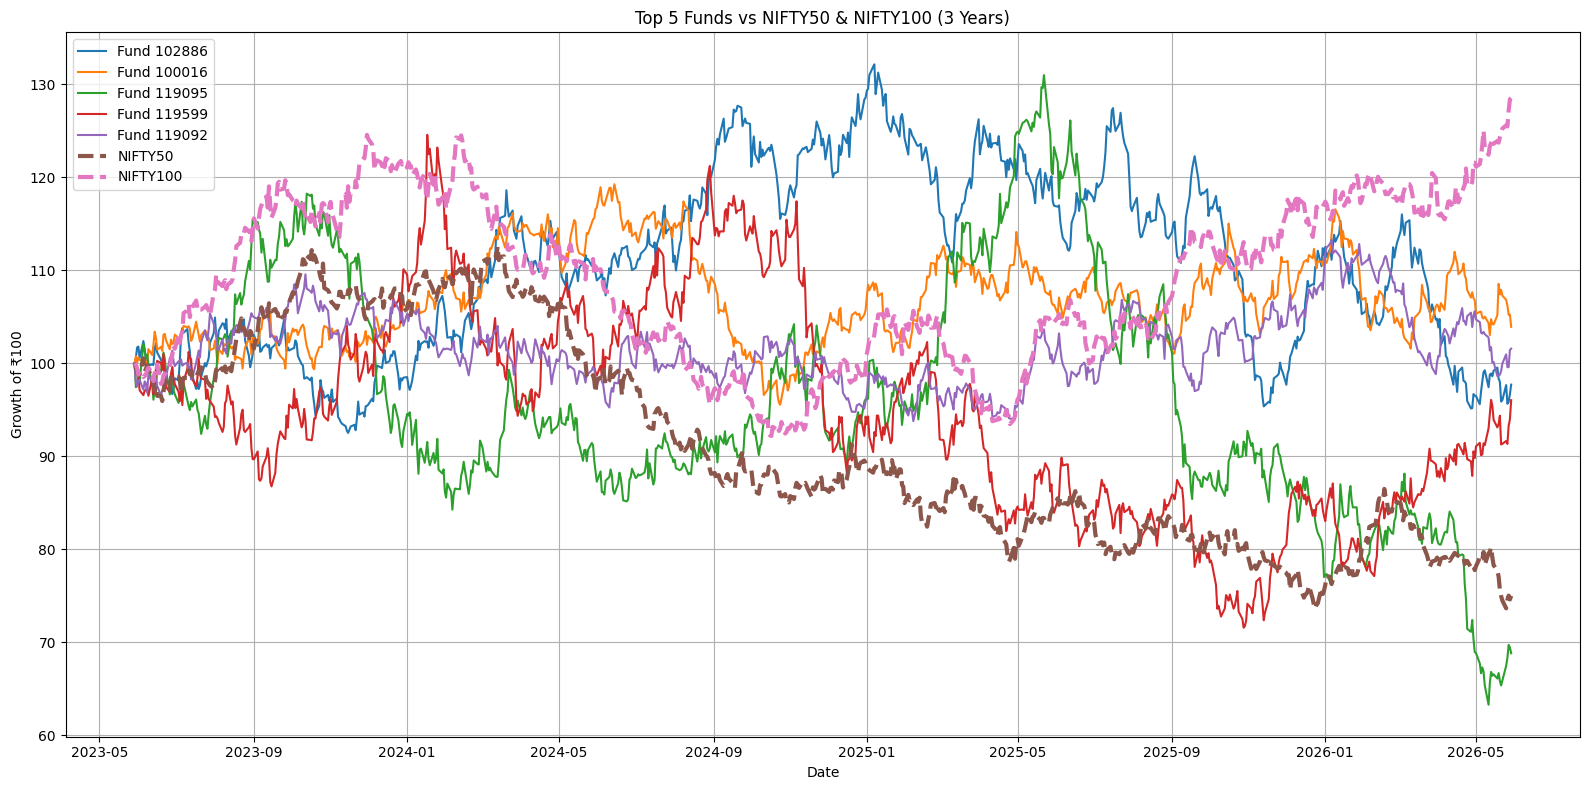

In [57]:
plt.figure(figsize=(16,8))

# Funds
for fund in top5_funds:

    temp = top5_nav[
        top5_nav['amfi_code'] == fund
    ]

    plt.plot(
        temp['date'],
        temp['normalized_nav'],
        label=f'Fund {fund}'
    )

# Benchmarks
for idx in ['NIFTY50', 'NIFTY100']:

    temp = bench[
        bench['index_name'] == idx
    ]

    plt.plot(
        temp['date'],
        temp['normalized_index'],
        linewidth=3,
        linestyle='--',
        label=idx
    )

plt.title(
    "Top 5 Funds vs NIFTY50 & NIFTY100 (3 Years)"
)

plt.xlabel("Date")
plt.ylabel("Growth of ₹100")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../reports/charts/benchmark_comparison.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Tracking Error

Formula:

TrackingError=Std(FundReturn−BenchmarkReturn)

In [58]:
nifty100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

nifty100['benchmark_return'] = (
    nifty100['close_value']
    .pct_change()
)

In [61]:
print(top5_funds)

[102886, 100016, 119095, 119599, 119092]


In [64]:
def tracking_error(fund_code):

    fund = nav[
        nav['amfi_code'] == fund_code
    ].copy()

    merged = pd.merge(
        fund[['date','daily_return']],
        nifty100[
            ['date','benchmark_return']
        ],
        on='date'
    )

    return (
        merged['daily_return']
        -
        merged['benchmark_return']
    ).std() * np.sqrt(252)

In [65]:
tracking_errors = []

for fund in top5_funds:

    te = tracking_error(fund)

    tracking_errors.append(
        [fund, te]
    )

tracking_error_df = pd.DataFrame(
    tracking_errors,
    columns=[
        'amfi_code',
        'tracking_error'
    ]
)

tracking_error_df

,amfi_code,tracking_error
0,102886,0.225608
1,100016,0.199284
2,119095,0.285781
3,119599,0.277135
4,119092,0.189082


In [66]:
tracking_error_df.to_csv(
    "../reports/tracking_error.csv",
    index=False
)

print("tracking_error.csv saved")

tracking_error.csv saved


Dash board data converted tables to csv files from db 


In [1]:
import sqlite3
import pandas as pd
import os

conn = sqlite3.connect("../data/db/bluestock_mf.db")

tables = [
    "dim_fund",
    "fact_nav",
    "fact_transactions",
    "fact_performance",
    "fact_aum"
]

os.makedirs("../dashboard_data", exist_ok=True)

for table in tables:
    df = pd.read_sql(
        f"SELECT * FROM {table}",
        conn
    )

    df.to_csv(
        f"../dashboard_data/{table}.csv",
        index=False
    )

    print(f"Exported {table}")

conn.close()

Exported dim_fund
Exported fact_nav
Exported fact_transactions
Exported fact_performance
Exported fact_aum
